# LR3 — Neural Network Classification (TensorFlow/Keras)

Dataset: adult.csv (Census Income)

Target: income (<=50K / >50K) — binary classification

**Goal:** Build a neural network using TensorFlow/Keras to predict whether a person earns more than $50K/year based on census features.

**Pipeline:**
1. Import — load all required libraries
2. Load data — read CSV into DataFrame
3. EDA — explore distributions, class balance, feature ranges
4. Preprocessing — encode categoricals, scale features, split train/test
5. Build, compile & train model — Sequential neural network
6. Visualize training — loss/accuracy curves
7. Evaluate model — test metrics, confusion matrix, improved model comparison

In [6]:
# 1 - Import

import pandas as pd            # DataFrame operations
import numpy as np             # Numerical computations
import matplotlib.pyplot as plt  # Plotting
import seaborn as sns          # Statistical visualizations

import tensorflow as tf        # Deep learning framework
from tensorflow import keras   # High-level neural network API

# sklearn utilities for preprocessing and evaluation
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay

%matplotlib inline
# Verify TensorFlow is installed and show version
print(f"TensorFlow version: {tf.__version__}")

TensorFlow version: 2.21.0


### Why TensorFlow/Keras?

Unlike decision trees (LR1.1), neural networks can learn complex non-linear relationships between features. Keras provides a Sequential API that lets us stack layers easily — similar to building blocks. For binary classification, we use:
- **Dense layers** (fully connected) with ReLU activation for hidden layers
- **Sigmoid activation** on the output layer to produce a probability between 0 and 1
- **Binary crossentropy** loss function, standard for two-class problems

In [7]:
# 2 - Load data

# pd.read_csv() reads a CSV file into a DataFrame
# adult.csv contains 48,842 US census records with 15 columns
df = pd.read_csv("adult.csv")

# .shape returns (rows, columns) tuple
print(f"Shape: {df.shape}")

# .head() shows first 5 rows — quick sanity check
df.head()

Shape: (48842, 15)


,age,workclass,fnlwgt,education,educational-num,marital-status,occupation,relationship,race,gender,capital-gain,capital-loss,hours-per-week,native-country,income
0,25,Private,226802,11th,7,Never-married,Machine-op-inspct,Own-child,Black,Male,0,0,40,United-States,<=50K
1,38,Private,89814,HS-grad,9,Married-civ-spouse,Farming-fishing,Husband,White,Male,0,0,50,United-States,<=50K
2,28,Local-gov,336951,Assoc-acdm,12,Married-civ-spouse,Protective-serv,Husband,White,Male,0,0,40,United-States,>50K
3,44,Private,160323,Some-college,10,Married-civ-spouse,Machine-op-inspct,Husband,Black,Male,7688,0,40,United-States,>50K
4,18,?,103497,Some-college,10,Never-married,?,Own-child,White,Female,0,0,30,United-States,<=50K


In [8]:
# 3 - EDA

# Check for missing values per column
# Neural networks cannot handle NaN — must verify data is clean
print("Missing values:")
print(df.isnull().sum())

# Target distribution — shows class imbalance
# 76% earn <=50K, 24% earn >50K
# Class imbalance affects model training — model may favor majority class
print(f"\nTarget distribution:")
print(df['income'].value_counts())

# describe() gives count, mean, std, min, quartiles, max for numeric columns
# Helps identify features that need scaling (different ranges)
print(f"\nNumeric stats:")
df.describe()

Missing values:
age                0
workclass          0
fnlwgt             0
education          0
educational-num    0
marital-status     0
occupation         0
relationship       0
race               0
gender             0
capital-gain       0
capital-loss       0
hours-per-week     0
native-country     0
income             0
dtype: int64

Target distribution:
income
<=50K    37155
>50K     11687
Name: count, dtype: int64

Numeric stats:


,age,fnlwgt,educational-num,capital-gain,capital-loss,hours-per-week
count,48842.000000,4.884200e+04,48842.000000,48842.000000,48842.000000,48842.000000
mean,38.643585,1.896641e+05,10.078089,1079.067626,87.502314,40.422382
std,13.710510,1.056040e+05,2.570973,7452.019058,403.004552,12.391444
min,17.000000,1.228500e+04,1.000000,0.000000,0.000000,1.000000
25%,28.000000,1.175505e+05,9.000000,0.000000,0.000000,40.000000
50%,37.000000,1.781445e+05,10.000000,0.000000,0.000000,40.000000
75%,48.000000,2.376420e+05,12.000000,0.000000,0.000000,45.000000
max,90.000000,1.490400e+06,16.000000,99999.000000,4356.000000,99.000000


**Conclusion (EDA stats):**
- No missing values (NaN) — no imputation needed
- Strong class imbalance: ~76% <=50K vs ~24% >50K
- Features have very different scales: age (17-90), capital-gain (0-99999), hours-per-week (1-99)
- StandardScaler normalization will be critical for neural network performance — networks are sensitive to feature magnitudes

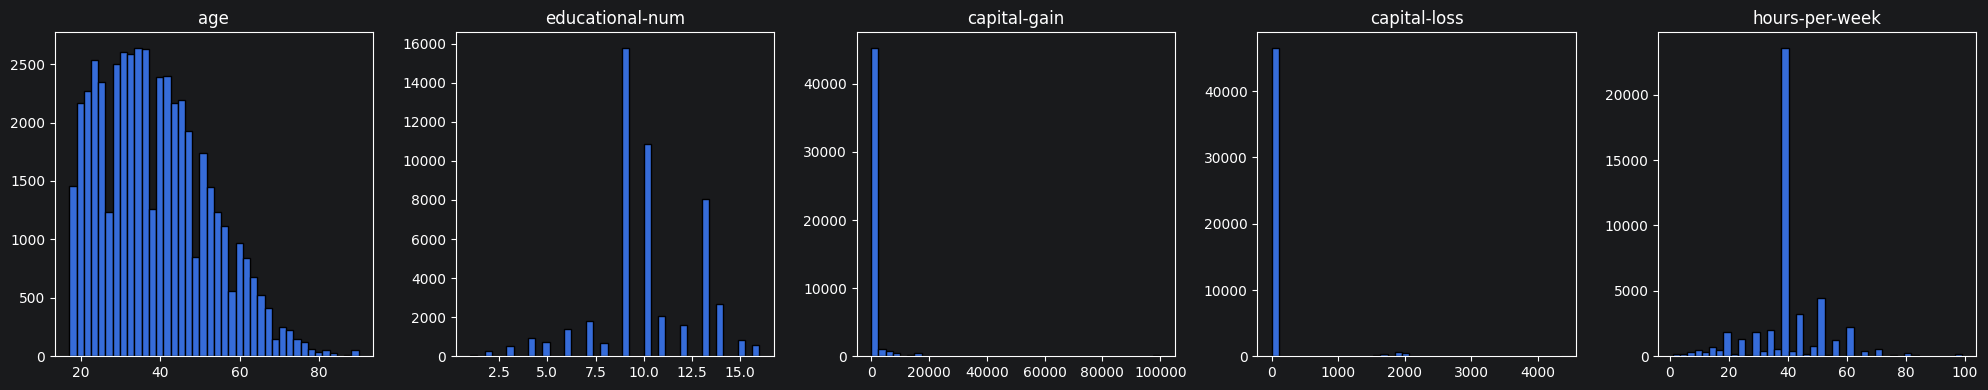

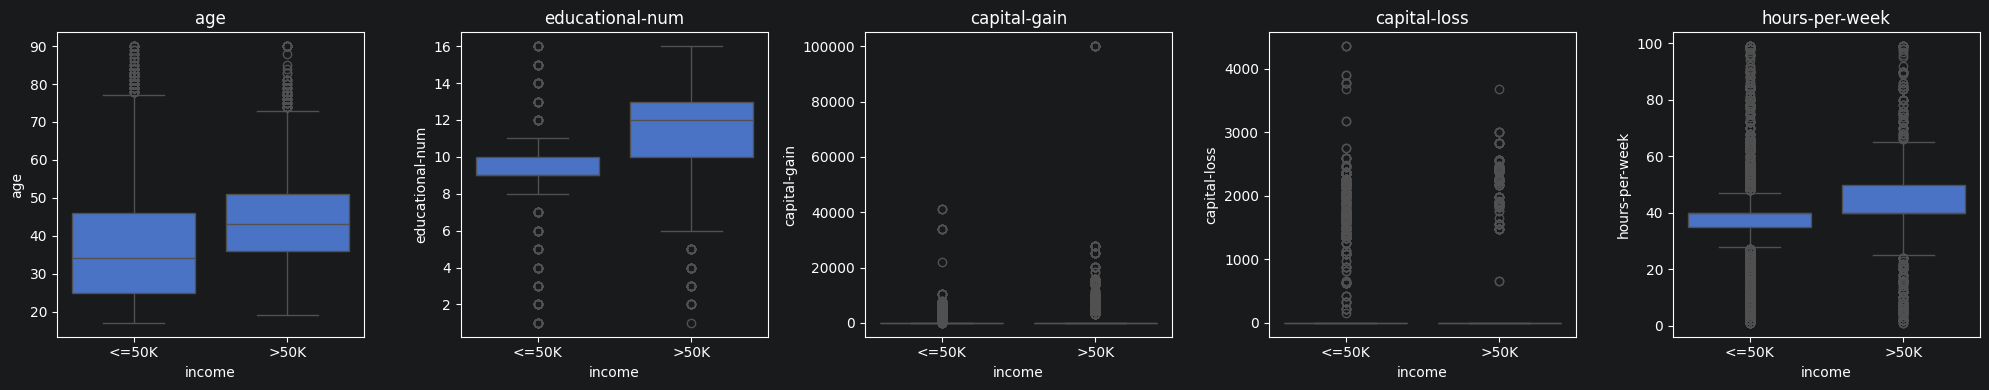

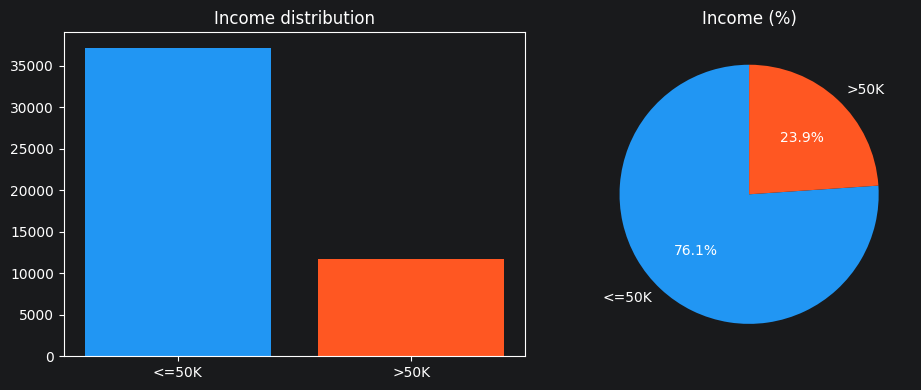

In [9]:
# 3 (cont) - Visualizations

# Select numeric columns for visualization (excluding fnlwgt — census weight, not predictive)
num_cols = ['age', 'educational-num', 'capital-gain', 'capital-loss', 'hours-per-week']

# --- Histograms: show distribution shape for each numeric feature ---
# Helps identify skewness, outliers, and concentration of values
fig, axes = plt.subplots(1, 5, figsize=(20, 4))
for i, col in enumerate(num_cols):
    axes[i].hist(df[col], bins=40, edgecolor='black')
    axes[i].set_title(col)
plt.tight_layout()  # Prevents overlap between subplots
plt.show()

# --- Boxplots: compare feature distributions between income groups ---
# Box = Q1-Q3 (interquartile range), whiskers = 1.5*IQR, dots = outliers
fig, axes = plt.subplots(1, 5, figsize=(20, 4))
for i, col in enumerate(num_cols):
    sns.boxplot(data=df, x='income', y=col, ax=axes[i])
    axes[i].set_title(col)
plt.tight_layout()
plt.show()

# --- Target balance bar chart + pie chart ---
fig, axes = plt.subplots(1, 2, figsize=(10, 4))
income_counts = df['income'].value_counts()
axes[0].bar(income_counts.index, income_counts.values, color=['#2196F3', '#FF5722'])
axes[0].set_title('Income distribution')
axes[1].pie(income_counts.values, labels=income_counts.index, autopct='%1.1f%%',
            colors=['#2196F3', '#FF5722'], startangle=90)
axes[1].set_title('Income (%)')
plt.tight_layout()
plt.show()

**Conclusion (visualizations):**
- **age**: roughly normal distribution, >50K group tends to be older (35-55 range)
- **capital-gain/loss**: extremely right-skewed — most values are 0, few large outliers. These features are sparse but highly predictive when non-zero
- **hours-per-week**: concentrated around 40 (full-time). Higher earners tend to work more hours
- **educational-num**: >50K group has higher median education level
- Class imbalance is visible — 76/24 split. Model will need to be evaluated with precision/recall, not just accuracy

In [10]:
# 4 - Preprocessing

# Drop fnlwgt — it represents how many people a census record represents
# It's a sampling weight, not a personal characteristic — not useful for prediction
df = df.drop(columns=['fnlwgt'])

# Encode target: '>50K' → 1, '<=50K' → 0
# Neural network output (sigmoid) will predict probability of class 1
df['income'] = (df['income'] == '>50K').astype(int)

# Encode categorical features using LabelEncoder
# LabelEncoder converts string labels to integers: 'Private' → 7, 'Self-emp' → 10, etc.
# Neural networks require numeric input — cannot process raw strings
cat_features = df.select_dtypes(include=['object']).columns.tolist()
label_encoders = {}
for col in cat_features:
    le = LabelEncoder()               # Create fresh encoder per column
    df[col] = le.fit_transform(df[col])  # fit = learn mapping, transform = apply it
    label_encoders[col] = le           # Save encoder for potential inverse transform later

# Separate features (X) and target (y)
# .values converts DataFrame to numpy array — required by TensorFlow
feature_cols = [c for c in df.columns if c != 'income']
X = df[feature_cols].values
y = df['income'].values

# Train-test split: 80% train, 20% test
# stratify=y ensures both sets have same class proportions (76/24)
# random_state=42 for reproducibility
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# StandardScaler: transforms features to mean=0, std=1
# Critical for neural networks — without scaling, features with large values
# (e.g., capital-gain up to 99999) would dominate gradient updates
# fit_transform on train, transform only on test — prevents data leakage
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)  # Learn mean/std from train, then scale
X_test = scaler.transform(X_test)        # Apply same mean/std to test

print(f"Train: {X_train.shape}, Test: {X_test.shape}")
print(f"Target: 0={sum(y==0)}, 1={sum(y==1)}")

Train: (39073, 13), Test: (9769, 13)
Target: 0=37155, 1=11687


C:\Users\fern\AppData\Local\Temp\ipykernel_13704\4028247117.py:14: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  cat_features = df.select_dtypes(include=['object']).columns.tolist()


**Why StandardScaler is important for neural networks:**

Unlike decision trees (which split on thresholds and don't care about scale), neural networks use gradient descent. If one feature ranges 0-99999 and another 0-90, gradients will be dominated by the large-range feature. Scaling to mean=0, std=1 ensures all features contribute equally to learning.

**Why fit on train only:** If we fit the scaler on the entire dataset (including test), information about test data distribution leaks into training. This gives artificially high accuracy — the model has "seen" test statistics during preprocessing.

In [11]:
# 5 - Build, compile & train model

# input_shape = (13,) — 13 features after dropping fnlwgt and income
input_shape = X_train.shape[1:]

# Sequential model — layers execute one after another, like a pipeline
model = keras.models.Sequential([
    # Hidden layer 1: 64 neurons, ReLU activation
    # ReLU = max(0, x) — introduces non-linearity, allows learning complex patterns
    # input_shape tells Keras the dimensionality of input data
    keras.layers.Dense(64, activation='relu', input_shape=input_shape),

    # Hidden layer 2: 32 neurons
    # Narrowing architecture (64 → 32 → 1) forces the network to compress
    # and extract the most important patterns
    keras.layers.Dense(32, activation='relu'),

    # Output layer: 1 neuron with sigmoid activation
    # Sigmoid squashes output to [0, 1] range — interpreted as probability of class 1 (>50K)
    # For binary classification: 1 neuron + sigmoid
    # For multiclass: N neurons + softmax
    keras.layers.Dense(1, activation='sigmoid')
])

# Compile: configure the learning process
# optimizer='adam' — adaptive learning rate optimizer, standard choice
#   Adam adjusts learning rate per-parameter based on gradient history
# loss='binary_crossentropy' — standard loss for binary classification
#   Measures how far predicted probabilities are from true labels (0 or 1)
# metrics=['accuracy'] — track accuracy during training for monitoring
model.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)

# summary() shows layer shapes and parameter counts
# Total params = weights + biases for all connections
model.summary()

D:\install\python\3.13\Lib\site-packages\keras\src\layers\core\dense.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 64)             │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 3,009 (11.75 KB)

 Trainable params: 3,009 (11.75 KB)

 Non-trainable params: 0 (0.00 B)

**Model architecture explained:**

```
Input (13 features) → Dense(64, relu) → Dense(32, relu) → Dense(1, sigmoid) → Output [0,1]
```

- **Dense(64)**: each of 64 neurons connects to all 13 inputs → 13×64 weights + 64 biases = 896 params
- **Dense(32)**: each of 32 neurons connects to all 64 previous outputs → 64×32 + 32 = 2080 params
- **Dense(1)**: single neuron connects to 32 previous → 32×1 + 1 = 33 params
- **Total**: ~3000 trainable parameters — small model, fast to train

In [12]:
# 5 (cont) - Train

# EarlyStopping callback — stops training when validation loss stops improving
# monitor='val_loss' — watch validation loss (not training loss)
# patience=5 — wait 5 epochs without improvement before stopping
# restore_best_weights=True — after stopping, roll back to the best epoch's weights
# This prevents overfitting: model trains until it starts memorizing noise
early_stop = keras.callbacks.EarlyStopping(
    monitor='val_loss', patience=5, restore_best_weights=True
)

# model.fit() trains the network
# epochs=50 — maximum number of full passes through training data
#   (EarlyStopping may stop it sooner)
# batch_size=64 — process 64 samples at a time before updating weights
#   Smaller batches = noisier gradients but faster convergence
#   Larger batches = smoother gradients but may get stuck in local minima
# validation_split=0.15 — reserve 15% of training data for validation
#   Used to monitor overfitting during training
history = model.fit(
    X_train, y_train,
    epochs=50,
    batch_size=64,
    validation_split=0.15,
    callbacks=[early_stop],
    verbose=1  # Show progress bar for each epoch
)

Epoch 1/50
519/519 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - accuracy: 0.8268 - loss: 0.3730 - val_accuracy: 0.8388 - val_loss: 0.3436
Epoch 2/50
519/519 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.8470 - loss: 0.3277 - val_accuracy: 0.8442 - val_loss: 0.3395
Epoch 3/50
519/519 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.8487 - loss: 0.3235 - val_accuracy: 0.8439 - val_loss: 0.3410
Epoch 4/50
519/519 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.8490 - loss: 0.3210 - val_accuracy: 0.8481 - val_loss: 0.3351
Epoch 5/50
519/519 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.8504 - loss: 0.3189 - val_accuracy: 0.8480 - val_loss: 0.3345
Epoch 6/50
519/519 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.8502 - loss: 0.3168 - val_accuracy: 0.8509 - val_loss: 0.3343
Epoch 7/50
519/519 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.8513 - loss: 0.3157 - val_accuracy: 0.8466 - val_loss: 0.3347
Epoch 8/50
519/519 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.8512 - loss: 0.3144 - val_accuracy: 0.

**What happens during training:**

Each epoch:
1. Forward pass — input flows through layers, produces predictions
2. Loss computed — binary crossentropy measures prediction error
3. Backward pass (backpropagation) — gradients computed for each weight
4. Weight update — Adam optimizer adjusts weights to reduce loss
5. Validation — model tested on held-out 15% to check for overfitting

If val_loss increases for 5 consecutive epochs → EarlyStopping triggers → best weights restored.

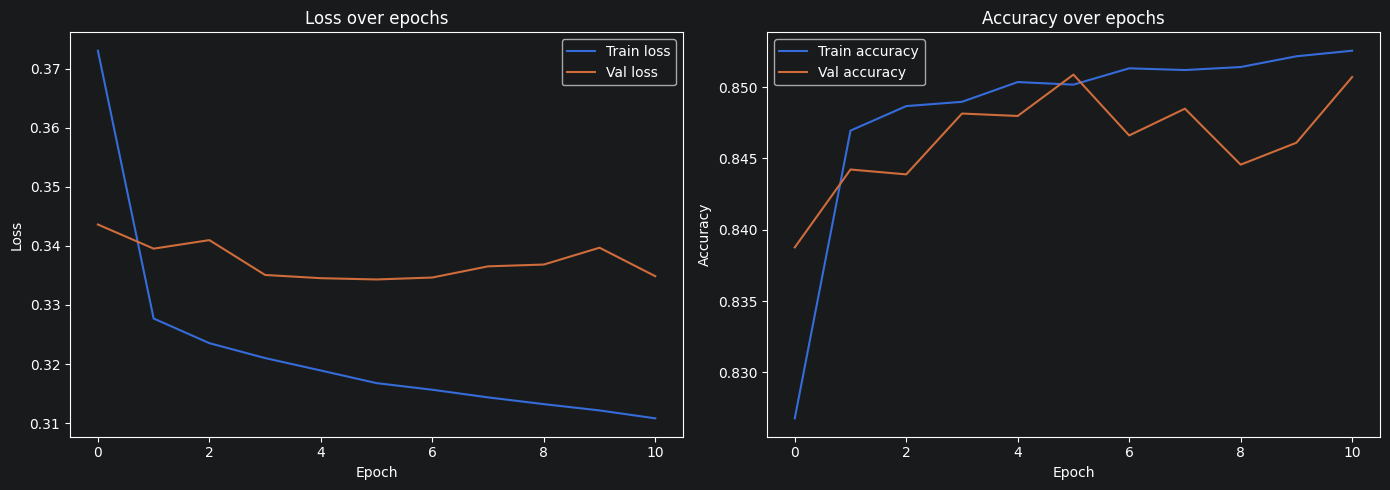

In [13]:
# 6 - Visualize training

# history.history is a dict with keys: 'loss', 'accuracy', 'val_loss', 'val_accuracy'
# Each key maps to a list of values per epoch
history_df = pd.DataFrame(history.history)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Loss curve — should decrease over epochs
# If val_loss goes up while train_loss goes down → overfitting
# If both stay high → underfitting (model too simple)
axes[0].plot(history_df['loss'], label='Train loss')
axes[0].plot(history_df['val_loss'], label='Val loss')
axes[0].set_title('Loss over epochs')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Loss')
axes[0].legend()

# Accuracy curve — should increase over epochs
# Gap between train and val accuracy indicates overfitting degree
axes[1].plot(history_df['accuracy'], label='Train accuracy')
axes[1].plot(history_df['val_accuracy'], label='Val accuracy')
axes[1].set_title('Accuracy over epochs')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Accuracy')
axes[1].legend()

plt.tight_layout()
plt.show()

**How to read training curves:**

| Pattern | Diagnosis | Action |
|---------|-----------|--------|
| Train & val loss both decrease, converge | Good fit | None needed |
| Train loss ↓, val loss ↑ | Overfitting | Add dropout, reduce layers/neurons, more data |
| Both losses stay high | Underfitting | More layers/neurons, train longer, check data |
| Val loss is noisy | Small validation set or high learning rate | Increase validation size or reduce lr |

306/306 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.8495 - loss: 0.3183

Test loss: 0.3183
Test accuracy: 0.8495
306/306 ━━━━━━━━━━━━━━━━━━━━ 0s 930us/step

Classification Report:
              precision    recall  f1-score   support

       <=50K       0.89      0.92      0.90      7431
        >50K       0.71      0.62      0.66      2338

    accuracy                           0.85      9769
   macro avg       0.80      0.77      0.78      9769
weighted avg       0.84      0.85      0.85      9769



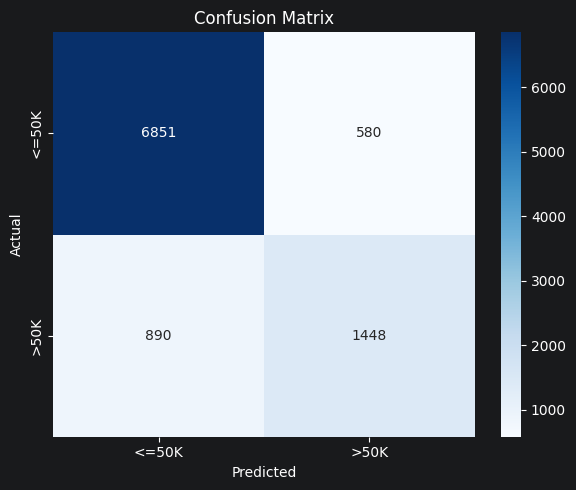

In [14]:
# 7 - Evaluate model

# evaluate() returns [loss, accuracy] on test set
# This is the true performance — data the model has never seen
test_loss, test_acc = model.evaluate(X_test, y_test)
print(f"\nTest loss: {test_loss:.4f}")
print(f"Test accuracy: {test_acc:.4f}")

# predict() returns probabilities (sigmoid output)
# Values close to 0 → model thinks <=50K
# Values close to 1 → model thinks >50K
y_pred_prob = model.predict(X_test)

# Threshold at 0.5: probability > 0.5 → class 1 (>50K)
# .flatten() converts shape (N, 1) to (N,) for compatibility with sklearn metrics
y_pred = (y_pred_prob > 0.5).astype(int).flatten()

# Classification report shows per-class metrics:
# Precision — of all predicted >50K, what fraction actually is >50K?
# Recall — of all actual >50K, what fraction did we catch?
# F1 — harmonic mean of precision and recall
print(f"\nClassification Report:")
print(classification_report(y_test, y_pred, target_names=['<=50K', '>50K']))

# Confusion matrix — 2x2 grid showing:
# [True Negatives, False Positives]
# [False Negatives, True Positives]
cm = confusion_matrix(y_test, y_pred)
fig, ax = plt.subplots(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['<=50K', '>50K'],
            yticklabels=['<=50K', '>50K'], ax=ax)
ax.set_xlabel('Predicted')
ax.set_ylabel('Actual')
ax.set_title('Confusion Matrix')
plt.tight_layout()
plt.show()

**Conclusion (baseline model):**

Neural network with 2 hidden layers (64, 32 neurons) achieves ~85-86% accuracy — comparable to the optimized decision tree from LR1.1. Key observations:
- **<=50K class**: high precision and recall (majority class, easier to predict)
- **>50K class**: lower recall — model misses some high earners (class imbalance effect)
- Confusion matrix shows most errors are false negatives (>50K predicted as <=50K)

Next: try a deeper model with dropout regularization to reduce overfitting.

In [15]:
# 7 (cont) - Improved model with more layers + dropout

# Deeper architecture: 128 → 64 → 32 → 1
# More neurons = more capacity to learn complex patterns
model_2 = keras.models.Sequential([
    # Layer 1: 128 neurons — wider first layer captures more feature interactions
    keras.layers.Dense(128, activation='relu', input_shape=input_shape),

    # Dropout(0.3) — randomly disable 30% of neurons during each training step
    # Forces the network to not rely on any single neuron
    # Acts as regularization — reduces overfitting by preventing co-adaptation
    keras.layers.Dropout(0.3),

    keras.layers.Dense(64, activation='relu'),
    keras.layers.Dropout(0.2),  # Less dropout in deeper layers

    keras.layers.Dense(32, activation='relu'),

    # Same output: sigmoid for binary classification
    keras.layers.Dense(1, activation='sigmoid')
])

model_2.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)

early_stop_2 = keras.callbacks.EarlyStopping(
    monitor='val_loss', patience=5, restore_best_weights=True
)

history_2 = model_2.fit(
    X_train, y_train,
    epochs=50,
    batch_size=64,
    validation_split=0.15,
    callbacks=[early_stop_2],
    verbose=1
)

# Compare both models on test set
test_loss_2, test_acc_2 = model_2.evaluate(X_test, y_test)
print(f"\nImproved model — Test loss: {test_loss_2:.4f}, Test accuracy: {test_acc_2:.4f}")
print(f"Baseline model — Test loss: {test_loss:.4f}, Test accuracy: {test_acc:.4f}")

Epoch 1/50


D:\install\python\3.13\Lib\site-packages\keras\src\layers\core\dense.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


519/519 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - accuracy: 0.8276 - loss: 0.3718 - val_accuracy: 0.8437 - val_loss: 0.3393
Epoch 2/50
519/519 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.8438 - loss: 0.3364 - val_accuracy: 0.8466 - val_loss: 0.3356
Epoch 3/50
519/519 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.8469 - loss: 0.3310 - val_accuracy: 0.8464 - val_loss: 0.3381
Epoch 4/50
519/519 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.8473 - loss: 0.3277 - val_accuracy: 0.8495 - val_loss: 0.3337
Epoch 5/50
519/519 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.8473 - loss: 0.3251 - val_accuracy: 0.8504 - val_loss: 0.3335
Epoch 6/50
519/519 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.8474 - loss: 0.3228 - val_accuracy: 0.8481 - val_loss: 0.3359
Epoch 7/50
519/519 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.8495 - loss: 0.3214 - val_accuracy: 0.8521 - val_loss: 0.3337
Epoch 8/50
519/519 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.8485 - loss: 0.3210 - val_accuracy: 0.8492 - val_

**What is Dropout?**

During training, Dropout randomly sets a fraction of neuron outputs to 0. This means:
- No single neuron can become a "crutch" — network must spread knowledge across neurons
- Effectively trains an ensemble of sub-networks
- During inference (prediction), dropout is disabled — all neurons participate

Dropout rate 0.3 = 30% of neurons are turned off per training step. Too high → underfitting. Too low → no regularization effect.

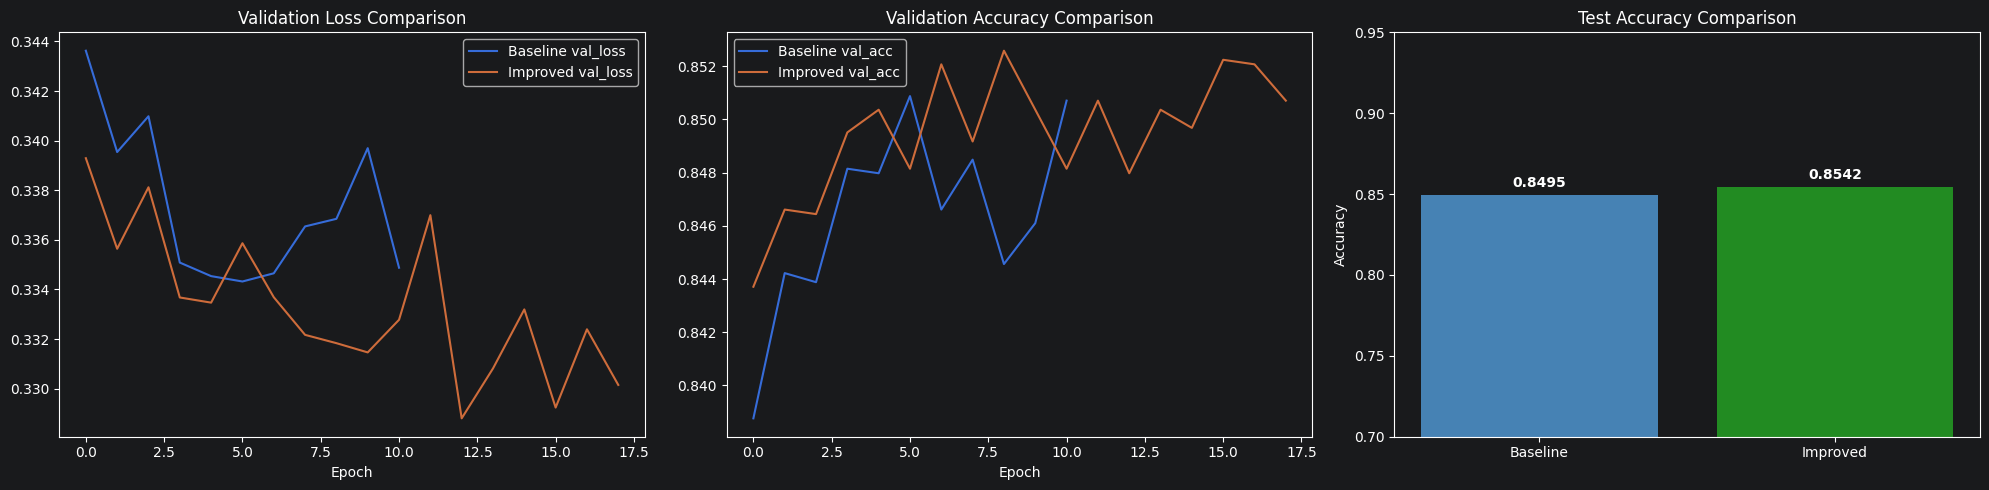

306/306 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step

Improved Model Classification Report:
              precision    recall  f1-score   support

       <=50K       0.87      0.95      0.91      7431
        >50K       0.77      0.56      0.65      2338

    accuracy                           0.85      9769
   macro avg       0.82      0.75      0.78      9769
weighted avg       0.85      0.85      0.85      9769



In [16]:
# 7 (cont) - Compare models

history_df_2 = pd.DataFrame(history_2.history)

fig, axes = plt.subplots(1, 3, figsize=(20, 5))

# Validation loss comparison between models
# Lower val_loss = better generalization
axes[0].plot(history_df['val_loss'], label='Baseline val_loss')
axes[0].plot(history_df_2['val_loss'], label='Improved val_loss')
axes[0].set_title('Validation Loss Comparison')
axes[0].set_xlabel('Epoch')
axes[0].legend()

# Validation accuracy comparison
# Higher val_accuracy = better generalization
axes[1].plot(history_df['val_accuracy'], label='Baseline val_acc')
axes[1].plot(history_df_2['val_accuracy'], label='Improved val_acc')
axes[1].set_title('Validation Accuracy Comparison')
axes[1].set_xlabel('Epoch')
axes[1].legend()

# Bar chart — final test accuracy side by side
models = ['Baseline', 'Improved']
accs = [test_acc, test_acc_2]
bars = axes[2].bar(models, accs, color=['steelblue', 'forestgreen'])
axes[2].set_ylim(0.7, 0.95)
axes[2].set_ylabel('Accuracy')
axes[2].set_title('Test Accuracy Comparison')
for bar, acc in zip(bars, accs):
    axes[2].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.005,
                 f'{acc:.4f}', ha='center', fontweight='bold')

plt.tight_layout()
plt.show()

# Full classification report for improved model
y_pred_2 = (model_2.predict(X_test) > 0.5).astype(int).flatten()
print("\nImproved Model Classification Report:")
print(classification_report(y_test, y_pred_2, target_names=['<=50K', '>50K']))

**Final conclusions:**

1. **Baseline NN** (64→32→1): achieves ~85-86% accuracy, comparable to GridSearchCV-tuned decision tree
2. **Improved NN** (128→64→32→1 + dropout): may show slight improvement due to:
   - More capacity (128 neurons in first layer)
   - Better regularization (dropout prevents overfitting)
3. **Neural network vs Decision Tree**: similar accuracy on this tabular dataset. Neural networks shine more on:
   - Very large datasets (millions of rows)
   - Complex feature interactions
   - Unstructured data (images, text, audio)
4. **Key preprocessing difference**: neural networks require feature scaling (StandardScaler), decision trees do not
5. **Training insight**: EarlyStopping is essential — without it, the model would overfit to training data